<a href="https://colab.research.google.com/github/AhmadSyahreza/Katanya-kami-lomba/blob/main/Awal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Katanya Kami Lomba

Notebook ini digunakan untuk coding dan analisis data.

In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/train.csv')
test1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/test.csv')
holidays = pd.read_csv('/content/drive/MyDrive/Lomba Data/holidays.csv')
movies = pd.read_csv('/content/drive/MyDrive/Lomba Data/movies.csv')
ticket_prices = pd.read_csv('/content/drive/MyDrive/Lomba Data/ticket_prices.csv')
test_history = pd.read_csv('/content/drive/MyDrive/Lomba Data/test_history.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/Lomba Data/sample_submission.csv')

In [5]:
holidays

,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
1,2025-04-02,weekday,normal,NaN
2,2025-04-03,weekday,normal,NaN
3,2025-04-04,friday,normal,NaN
4,2025-04-05,weekend,normal,NaN
...,...,...,...,...
361,2026-03-28,weekend,normal,NaN
362,2026-03-29,weekend,normal,NaN
363,2026-03-30,weekday,normal,NaN
364,2026-03-31,weekday,normal,NaN


In [6]:
movies

,original_title,age_rating,genre,producer,director,writer,casts
0,120 BAHADUR,Remaja,"Action, War","Farhan Akhtar, Amit Chandrra, Ritesh Sidhwani",Razneesh Ghai,Sumit Arora,"Ankit Siwach, Farhan Akhtar, Amitabh Bachchan,..."
1,"13 DAYS, 13 NIGHTS",Remaja,"Action, War","Dimitri Rassam, Ardavan Safaee",Martin Bourboulon,"Martin Bourboulon, Alexandre Smia, Mohamed Bid...","Roschdy Zem, Lyna Khoudri, Sidse Babett Knudse..."
2,28 YEARS LATER,Dewasa,Thriller,"Danny Boyle, Alex Garland, Peter Rice",Danny Boyle,"Danny Boyle, Alex Garland","Jodie Comer, Aaron Taylor-Johnson, Jack O'Conn..."
3,28 YEARS LATER: THE BONE TEMPLE,Dewasa,Thriller,"Danny Boyle, Alex Garland, Andrew Macdonald",Nia DaCosta,Alex Garland,"Ralph Fiennes, Alfie Williams, Jack O'Connell,..."
4,5 CENTIMETERS PER SECOND (ANIMATION),Remaja,Animation,"Makoto Shinkai, Jin Ho Chung",Makoto Shinkai,Makoto Shinkai,"Kenji Mizuhashi, Yoshimi Kondou, Satomi Hanamu..."
...,...,...,...,...,...,...,...
392,WUTHERING HEIGHTS,Dewasa,"Romance, Drama","Emerald Fennell, Josey McNamara, Margot Robbie",Emerald Fennell,"Emerald Fennell, Emily Bronte","Margot Robbie, Jacob Elordi, Hong Chau, Shazad..."
393,YAKIN NIKAH,Remaja,"Drama, Romance","Shierly Kosasih, Ervina Isleyen",Pritagita Arianegara,"Bene Dion Rajagukguk, Sigit Sulistyo, Erwin Wu","Enzy Storia, Maxime Bouttier, Jourdy Pranata, ..."
394,YOU ARE THE APPLE OF MY EYE,Remaja,"Drama, Romance",Song Dae-chan,Cho Young-myoung,"Giddens Ko, Cho Young-myoung","Jung Jin-young, Kim Da-hyun, Demian, Kim Yo-ha..."
395,YOUR LETTER,Semua Umur,Animation,-,Kim Yong-hwan,Jeong Eun-kyeong,"Lee Suhyun, Kim Min-ju, Min Seung-woo, Nam Doh..."


In [7]:

for df in [train1, test1, test_history]:
    df["date_show"] = pd.to_datetime(df["date_show"])
holidays["date"] = pd.to_datetime(holidays["date"])

print("Train shape :", train1.shape)
print("Test shape  :", test1.shape)
print("Train       :", train1["date_show"].min().date(), "sampai", train1["date_show"].max().date())
print("Test        :", test1["date_show"].min().date(), "sampai", test1["date_show"].max().date())

Train shape : (138959, 7)
Test shape  : (72611, 5)
Train       : 2025-04-01 sampai 2025-09-30
Test        : 2025-10-04 sampai 2026-03-27


In [8]:
train1.isnull().sum().to_frame("Total Missing value ")

,Total Missing value
date_show,0
cinema_ids,0
city_name,0
movie_title,0
total_ticket,0
occupation_rate,0
total_show,0


In [9]:
train1[["total_ticket", "occupation_rate", "total_show"]].describe().round(2)

,total_ticket,occupation_rate,total_show
count,138959.00,138959.00,138959.00
mean,354.12,28.33,7.73
std,725.93,22.62,11.01
min,1.00,0.00,1.00
25%,69.00,12.36,3.00
50%,161.00,21.84,5.00
75%,361.00,37.01,8.00
max,32845.00,100.00,285.00


                 total_ticket  occupation_rate  total_show
total_ticket            1.000            0.309       0.786
occupation_rate         0.309            1.000       0.004
total_show              0.786            0.004       1.000


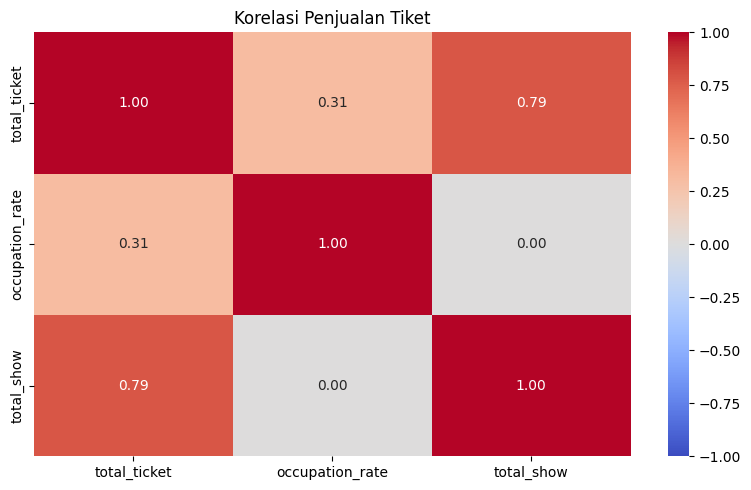

In [10]:
num_cols = [
    "total_ticket",
    "occupation_rate",
    "total_show"
]

corr = train1[num_cols].corr(method="pearson")

print(corr.round(3))

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Korelasi Penjualan Tiket")
plt.tight_layout()
plt.show()

In [11]:
film_test = set(test1['movie_title'])
film_movies = set(movies['original_title'])
film_missing = film_test - film_movies
kota_test = set(test1['city_name'])
kota_prices = set(ticket_prices['city_name'])
kota_missing = kota_test - kota_prices

summary_data = {
    "Kategori Pengecekan": ["Judul Film", "Nama Kota"],
    "Total Unik": [len(film_test), len(kota_test)],
    "Ada": [len(film_test - film_missing), len(kota_test - kota_missing)],
    "Missing": [len(film_missing), len(kota_missing)],
    "Status": [
        " film belum terdaftar" if len(film_missing) > 0 else "",
        " kota belum terdaftar" if len(kota_missing) > 0 else ""
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Kategori Pengecekan,Total Unik,Ada,Missing,Status
0,Judul Film,160,140,20,film belum terdaftar
1,Nama Kota,69,69,0,


In [12]:
df_missing_movies = pd.DataFrame({
    "Judul Missing": sorted((film_missing))
})

display(df_missing_movies)

,Judul Missing
0,AVATAR: FIRE AND ASH (3D)
1,AVATAR: FIRE AND ASH (IMAX 3D)
2,BLADES OF THE GUARDIANS (IMAX 2D)
3,DANUR: THE LAST CHAPTER (IMAX 2D)
4,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
5,HOPPERS (3D)
6,HOPPERS (IMAX 2D)
7,MERCY (IMAX 2D)
8,PREDATOR: BADLANDS (3D)
9,PREDATOR: BADLANDS (IMAX 2D)


In [13]:
def find_d1(df):
    nat = df.groupby(['movie_title','date_show'])['total_ticket'].sum().reset_index()
    first = nat.groupby('movie_title')['date_show'].min()
    out = {}
    for m, g in nat.groupby('movie_title'):
        ds = set(g['date_show'])
        for d in sorted(ds):
            if {d + pd.Timedelta(days=1), d + pd.Timedelta(days=2)} <= ds:
                out[m] = d
                break
    f = pd.Series(out, name='D1').rename_axis('movie_title').reset_index()
    f['first_date'] = f['movie_title'].map(first)
    return f

f = find_d1(train1)
tmin, tmax = train1['date_show'].min(), train1['date_show'].max()
f = f[(f['D1'] > tmin + pd.Timedelta(days=2)) &
      (f['D1'] + pd.Timedelta(days=9) <= tmax) &
      ((f['D1'] - f['first_date']).dt.days <= 3)].reset_index(drop=True)

print("jumlah film :", len(f), "dari", train1['movie_title'].nunique())
f.head()

jumlah film : 108 dari 237


,movie_title,D1,first_date
0,28 YEARS LATER,2025-06-17,2025-06-17
1,A BIG BOLD BEAUTIFUL JOURNEY,2025-09-18,2025-09-18
2,A MINECRAFT MOVIE,2025-04-04,2025-04-04
3,A MINECRAFT MOVIE (3D),2025-04-09,2025-04-09
4,A MINECRAFT MOVIE (IMAX 2D),2025-04-08,2025-04-08


Ini menggunakan komplikasi dari regresi linear, feature engineering, dan machine learning

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# --- 1. Konfigurasi Dasar & Reproduksibilitas ---
SEED = 2026
LABEL = "total_ticket"

train = pd.read_csv('/content/drive/MyDrive/Lomba Data/train.csv')
test_history = pd.read_csv('/content/drive/MyDrive/Lomba Data/test_history.csv')
test = pd.read_csv('/content/drive/MyDrive/Lomba Data/test.csv')
sub = pd.read_csv('/content/drive/MyDrive/Lomba Data/sample_submission.csv')

# --- 2. Fungsi MASE (Mean Absolute Scaled Error) ---
def hitung_skala(history):
    """
    history: tiga hari observasi (D1-D3) untuk tiap pasangan klaster-film
    """
    total = history.groupby(["movie_title", "cinema_ids"]).total_ticket.sum()
    return (total / 3).clip(lower=1).rename("scale")

def mean_absolute_scaled_error(y_true, y_pred, scale):
    """
    y_true: jumlah tiket terjual
    y_pred: forecast tiket terjual
    scale: rata-rata tiket terjual di tiga hari pertama
    """
    return mean_absolute_error(y_true / scale, y_pred / scale)

# --- 3. Feature Engineering: Mengambil 3 Hari Pertama sebagai Fitur & Skala ---
all_history = pd.concat([train, test_history], ignore_index=True)
all_history['date_show'] = pd.to_datetime(all_history['date_show'])
all_history = all_history.sort_values(['movie_title', 'cinema_ids', 'date_show'])

# Urutan hari tayang per film & bioskop
all_history['day_rank'] = all_history.groupby(['movie_title', 'cinema_ids']).cumcount() + 1
first_3_days = all_history[all_history['day_rank'] <= 3]

# Agregat fitur 3 hari pertama
features_3days = first_3_days.groupby(['movie_title', 'cinema_ids']).agg(
    ticket_day1_3=('total_ticket', 'sum'),
    show_day1_3=('total_show', 'sum'),
    occupation_day1_3=('occupation_rate', 'mean')
).reset_index()

# Hitung skala menggunakan fungsi yang diminta
scale_series = hitung_skala(first_3_days)
features_3days = features_3days.merge(scale_series, on=["movie_title", "cinema_ids"], how="left")

# --- 4. Persiapan Data Train dan Test ---
train['date_show'] = pd.to_datetime(train['date_show'])
train['day_rank'] = train.groupby(['movie_title', 'cinema_ids']).cumcount() + 1
train_merged = train.merge(features_3days, on=['movie_title', 'cinema_ids'], how='inner')

feature_cols = ['ticket_day1_3', 'show_day1_3', 'occupation_day1_3']
X = train_merged[feature_cols].fillna(0)
y = train_merged[LABEL]

# --- 5. Pelatihan Model menggunakan LightGBM Regressor ---
# Menggunakan LGBMRegressor karena target 'total_ticket' adalah variabel kontinu
model = lgb.LGBMRegressor(random_state=SEED, verbose=-1)
model.fit(X, y)

# --- 6. Prediksi pada Data Test ---
test = test.merge(features_3days, on=['movie_title', 'cinema_ids'], how='left')
X_test = test[feature_cols].fillna(0)

y_pred = model.predict(X_test)

# --- 7. Menyimpan Hasil Submisi ---
sub['total_ticket'] = y_pred
sub.to_csv('submission.csv', index=False)

print("Submisi berhasil dibuat dan konsisten dengan SEED:", SEED)
print(sub)

Submisi berhasil dibuat dan konsisten dengan SEED: 2026
          id  total_ticket
0          1     61.556404
1          2     61.556404
2          3     61.556404
3          4     61.556404
4          5     61.556404
...      ...           ...
72606  72607    148.797432
72607  72608    148.797432
72608  72609    148.797432
72609  72610    148.797432
72610  72611    148.797432

[72611 rows x 2 columns]


# **WINDOW**

Ini aku pakai window karena dari task paling utamanya diminta :
- data hari 1-3 terhadap minggu depannya
- berarti dalam 1 hari itu semua pertunjukan dan tiketnya seberapa ngaruh ke minggu depannya

In [ ]:
def build_windows(df): #DF nya dataset Train
    windows = []

    for (film, bioskop), group in df.groupby(['movie_title', 'cinema_ids']):
        group = group.sort_values('date_show').reset_index(drop=True)
        for start in range(len(group)):
            window = group.iloc[start:start+10] #Harusnya disini eror kalau ak ambil Y=iloc[6:9] [AWAL]
            if len(window) < 10:
                continue
            if (window['date_show'].diff()[1:] != pd.Timedelta(days=1)).any():
                continue

            X_window = window.iloc[0:3] #ini data dimana kita tarik hari(1-3) [FIX]
            Y_window = window.iloc[3:10] #Ini aku pakai default (01.52
           #Aku ganti ini we ke targetnya hari(1-4) tapi di minggu depannya (01.30) [EROR]
           #kode aslinya ini hari(4-10) [AWAL]
            windows.append({
                'cinema_ids': bioskop,
                'movie_title': film,
                'city_name': X_window.iloc[0]['city_name'],
                'date_D1': X_window.iloc[0]['date_show'],
                'd1': X_window.iloc[0]['total_ticket'],
                'd2': X_window.iloc[1]['total_ticket'],
                'd3': X_window.iloc[2]['total_ticket'],
                'target_4': Y_window.iloc[0]['total_ticket'],
                'target_5': Y_window.iloc[1]['total_ticket'],
                'target_6': Y_window.iloc[2]["total_ticket"],
                'target_7': Y_window.iloc[3]["total_ticket"],
                'target_8': Y_window.iloc[4]["total_ticket"],
                'target_9': Y_window.iloc[5]["total_ticket"],
                'target_10': Y_window.iloc[6]["total_ticket"]
                })

    return pd.DataFrame(windows)

# **DIBAWAH INI OPSIONAL (DATA SET PEMBANTU)**

In [ ]:
X_df = build_windows(train1)
n_awal = len(X_df)
print(X_df.shape)

# **Merge movies & ticket_prices**

In [ ]:
movies_u = movies.drop_duplicates("original_title")
X_df = X_df.merge(movies_u, left_on="movie_title", right_on="original_title", how="left")  #dari movies.csv
prices_num = ticket_prices.groupby("city_name", as_index=False).mean(numeric_only=True)
X_df = X_df.merge(prices_num, on="city_name", how="left") #Dari ticket_prices.csv
#Weekday/weekend/holiday

# Merge holidays

In [ ]:
holidays['date'] = pd.to_datetime(holidays['date'])
holidays_u = holidays.drop_duplicates("date")
X_df = X_df.merge(holidays_u, left_on="date_D1", right_on="date", how="left") #Ibarat mySQL join target day
#ini bisa nambahin kolom kategori/mapping kalau mau we

# Fitur tambahan


In [ ]:
X_df["avg_d1_d3"] = X_df[["d1", "d2", "d3"]].mean(axis=1)
X_df["dow_d1"] = X_df["date_D1"].dt.dayofweek
X_df["month_d1"] = X_df["date_D1"].dt.month
X_df["target_start_date"] = X_df["date_D1"] + pd.Timedelta(days=3)  # tanggal D4

# **BAGI DATANYA JADI 3**
TRAIN
VALIDASI
TEST

**Untuk semua data train gunain 2/3 utk kt train dan 1/3 utk validasi**

In [ ]:
train_mask = X_df["target_start_date"] < pd.Timestamp("2026-01-01")
if train_mask.sum() == 0 or (~train_mask).sum() == 0:
    cutoff = X_df["target_start_date"].quantile(0.8)
    train_mask = X_df["target_start_date"] < cutoff
    print("Cutoff diganti ke:", cutoff.date())

print("Train:", train_mask.sum(), "| Valid:", (~train_mask).sum())

# Y = hanya kolom target
Y_train = X_df.loc[train_mask, target_cols]
Y_valid = X_df.loc[~train_mask, target_cols]

# X = tanpa target, tanpa kolom tanggal
X_all = X_df.drop(columns=target_cols + ["target_start_date"])
X_all = X_all.drop(columns=X_all.select_dtypes(include="datetime64[ns]").columns)
X_all["cinema_ids"] = X_all["cinema_ids"].astype(str)

# Pisahkan kolom kategori & numerik
id_cols = ["movie_title", "original_title"]
obj_cols = [c for c in X_all.select_dtypes(exclude=np.number).columns if c not in id_cols]
cat_cols = [c for c in obj_cols if X_all[c].nunique() <= 100]   # buang teks panjang
num_cols_m = X_all.select_dtypes(include=np.number).columns.tolist()
X_all[cat_cols] = X_all[cat_cols].astype(str)

print("Kategori :", cat_cols)
print("Numerik  :", num_cols_m)

X_train = X_all.loc[train_mask]
X_valid = X_all.loc[~train_mask] #Ini negasinya

#[Valid] = NEGASI dari [Train]

# **import**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

target_cols = [f"target_{i}" for i in range(4, 11)]

# Model baseline

In [ ]:
avg_valid = X_df.loc[~train_mask, "avg_d1_d3"].values[:, None]
Y_pred_naive = np.repeat(avg_valid, len(target_cols), axis=1)
print("MAE (Naive) :", round(mean_absolute_error(Y_valid, Y_pred_naive), 3))

preprocess = ColumnTransformer([
    ("cat", make_pipeline(
        SimpleImputer(strategy="constant", fill_value="unknown"),
        OneHotEncoder(handle_unknown="ignore", min_frequency=5)
    ), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols_m),
])
X_train_encoded = preprocess.fit_transform(X_train[cat_cols + num_cols_m])
X_valid_encoded = preprocess.transform(X_valid[cat_cols + num_cols_m])

lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train_encoded, Y_train)
Y_pred_lr = np.clip(lr.predict(X_valid_encoded), 0, None)
print("MAE (Linear):", round(mean_absolute_error(Y_valid, Y_pred_lr), 3))

# Catboost


In [ ]:
!pip install catboost -q
import numpy as np
from catboost import CatBoostRegressor

X_train_cb = X_train[cat_cols + num_cols_m].copy()
X_valid_cb = X_valid[cat_cols + num_cols_m].copy()
X_train_cb[cat_cols] = X_train_cb[cat_cols].fillna("unknown")
X_valid_cb[cat_cols] = X_valid_cb[cat_cols].fillna("unknown")
for c in cat_cols:
    X_train_cb[c] = X_train_cb[c].astype(object).where(X_train_cb[c].notna(), "unknown").astype(str)
    X_valid_cb[c] = X_valid_cb[c].astype(object).where(X_valid_cb[c].notna(), "unknown").astype(str)

cat = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=500, learning_rate=0.1, depth=6,
        loss_function="MAE", verbose=0, random_seed=42
    )
)
cat.fit(X_train_cb, np.asarray(Y_train), cat_features=cat_cols)
Y_pred_cat = np.clip(cat.predict(X_valid_cb), 0, None)

def mean_absolute_scaled_error(y_true, y_pred, scale):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    scale = np.asarray(scale, float).reshape(-1, 1)
    return float(np.mean(np.abs(y_true - y_pred) / scale))

hasil["CatBoost"] = mean_absolute_scaled_error(Y_valid, Y_pred_cat, scale_valid)
print(f"MAE  CatBoost: {mean_absolute_error(Y_valid, Y_pred_cat):.3f}")
print(f"MASE CatBoost: {hasil['CatBoost']:.4f}")

# **DIBAWAH INI RUMUS MASE**

In [ ]:
def hitung_scale(avg_d1_d3):
    """scale = rata-rata tiket D1-D3 per film-bioskop, minimal 1"""
    return np.clip(np.asarray(avg_d1_d3, float), 1, None)[:, None]

def mean_absolute_scaled_error(y_true, y_pred, scale):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return np.mean(np.abs(y_true / scale - y_pred / scale))

scale_valid = hitung_scale(X_df.loc[~train_mask, "avg_d1_d3"])

hasil = {}
hasil["Naive"]  = mean_absolute_scaled_error(Y_valid, Y_pred_naive, scale_valid)
hasil["Linear"] = mean_absolute_scaled_error(Y_valid, Y_pred_lr, scale_valid)

for k, v in hasil.items():
    print(f"MASE {k:<8}: {v:.4f}")

## **CEKKK LAGII JANGAN LUPAA**

In [ ]:
import lightgbm as lgb

X_train_lgb = X_train[cat_cols + num_cols_m].copy()
X_valid_lgb = X_valid[cat_cols + num_cols_m].copy()

cat_levels = {}
for c in cat_cols:
    cat_levels[c] = pd.Categorical(X_train_lgb[c]).categories
    X_train_lgb[c] = pd.Categorical(X_train_lgb[c], categories=cat_levels[c])
    X_valid_lgb[c] = pd.Categorical(X_valid_lgb[c], categories=cat_levels[c])

params = {
    'objective': 'regression',
    'metric': 'l2',  # gunakan MSE untuk internal monitoring
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'seed': 42
}
lgb_models = {}
Y_pred_lgb = np.zeros((len(X_valid_lgb), len(target_cols)))

for j, t in enumerate(target_cols):
    dtr = lgb.Dataset(X_train_lgb, Y_train[t])
    dva = lgb.Dataset(X_valid_lgb, Y_valid[t], reference=dtr)
    m = lgb.train(
        params, dtr, num_boost_round=1000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    lgb_models[t] = m
    Y_pred_lgb[:, j] = m.predict(X_valid_lgb, num_iteration=m.best_iteration)
Y_pred_lgb = np.clip(Y_pred_lgb, 0, None)
hasil["LightGBM"] = mean_absolute_scaled_error(Y_valid, Y_pred_lgb, scale_valid)

# **JANGAN LUPA CEK**

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

preds = {"Naive": Y_pred_naive, "Linear": Y_pred_lr, "CatBoost": Y_pred_cat}

for nama, p in preds.items():
    print(f"{nama:<9} MAE={mean_absolute_error(Y_valid, p):8.2f}  "
          f"RMSE={root_mean_squared_error(Y_valid, p):8.2f}  "
          f"R2={r2_score(Y_valid, p):.4f}  "
          f"MASE={hasil[nama]:.4f}")

In [ ]:
print(test1.columns.tolist())
print(test_history.columns.tolist())
print(sample_submission.head())
print(test1.head(3))

# **INI UTK SUBMISSION**

In [ ]:
K = ["movie_title", "cinema_ids"]

#ambil history test (3 hari pertama tiap film-bioskop) buat jadi d1, d2, d3
th = test_history.sort_values("date_show")
first3 = th.groupby(K).head(3).copy()
first3["k"] = first3.groupby(K).cumcount() + 1
w = first3.pivot(index=K, columns="k", values="total_ticket").rename(columns={1: "d1", 2: "d2", 3: "d3"})

#ada pasangan yang history-nya cuma 1-2 hari, kolom yg kosong dibikin NaN aja
for c in ("d1", "d2", "d3"):
    if c not in w.columns:
        w[c] = np.nan

meta = th.groupby(K).agg(city_name=("city_name", "first"), date_D1=("date_show", "min"))
X_te = meta.join(w[["d1", "d2", "d3"]]).reset_index()
keys = X_te[K].copy()  #ini disimpen dulu sebelum cinema_ids diubah ke string

#merge-nya sama kayak di train
X_te = X_te.merge(movies_u, left_on="movie_title", right_on="original_title", how="left")
X_te = X_te.merge(prices_num, on="city_name", how="left")
X_te = X_te.merge(holidays_u, left_on="date_D1", right_on="date", how="left")
X_te["avg_d1_d3"] = X_te[["d1", "d2", "d3"]].mean(axis=1)
X_te["dow_d1"] = X_te["date_D1"].dt.dayofweek
X_te["month_d1"] = X_te["date_D1"].dt.month
X_te["cinema_ids"] = X_te["cinema_ids"].astype(str)
X_te[cat_cols] = X_te[cat_cols].astype(str)
X_te_cb = X_te.reindex(columns=cat_cols + num_cols_m)

X_full = X_all[cat_cols + num_cols_m].copy()
Y_full = X_df[target_cols].to_numpy()

#1 model per hari target (D4-D10), jadi looping 7 kali
pred = np.zeros((len(X_te_cb), len(target_cols)))
for i in range(len(target_cols)):
    m = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6,
                          loss_function="MAE", verbose=0, random_seed=42, cat_features=cat_cols)
    m.fit(X_full, Y_full[:, i])
    pred[:, i] = m.predict(X_te_cb)
pred = np.clip(pred, 0, None)  #nilai negatif jadi 0

pred_df = keys.copy()
pred_df[target_cols] = pred
long = pred_df.melt(id_vars=K, value_vars=target_cols, var_name="t", value_name="total_ticket")
long["step"] = long["t"].str.replace("target_", "").astype(int) - 3  #target_4 -> step 1, dst

#cocokin ke test.csv lewat urutan tanggal (hari ke-1 sampe ke-7 per pasangan)
tt = test1.sort_values("date_show").copy()
tt["step"] = tt.groupby(K).cumcount() + 1
sub = tt.merge(long[K + ["step", "total_ticket"]], on=K + ["step"], how="left")
submission = sample_submission[["id"]].merge(sub[["id", "total_ticket"]], on="id", how="left")

assert submission["total_ticket"].notna().all()
assert len(submission) == len(sample_submission)
submission.to_csv("submission.csv", index=False)
print(submission.head())

# **KORELASI KORELASI GRAFIK **

Malam ni tidur besok re check ke **claude**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/drive/MyDrive/Lomba Data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Lomba Data/test.csv")
history = pd.read_csv("/content/drive/MyDrive/Lomba Data/test_history.csv")

#da ku cocokkan ini ama data" yg di atas
train["date_show"] = pd.to_datetime(train["date_show"])
print(train.shape)
print(train.head())
print()
print()
print(train.info())

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(train["total_ticket"].clip(lower=0)),
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Ticket Sales")
plt.xlabel("log(1 + Total Ticket)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ALHAMDULILLAH PAS GRAFIKNYA

In [ ]:
ticket_prices = pd.read_csv("/content/drive/MyDrive/Lomba Data/ticket_prices.csv")
holidays = pd.read_csv("/content/drive/MyDrive/Lomba Data/holidays.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

daily_sales = train.groupby("date_show", as_index=False)["total_ticket"].sum()

In [ ]:
#AWAK BIKIN PERMINGGU
daily_sales["rolling_7d"] = (
    daily_sales["total_ticket"]
    .rolling(7, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date_show"],
    daily_sales["total_ticket"],
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date_show"],
    daily_sales["rolling_7d"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Ticket Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Tickets")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Grafiknya turun drastis ya. hmz
- oke good, ga lari banget


In [ ]:
train["day_of_week"] = train["date_show"].dt.dayofweek

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

train["day_name"] = train["day_of_week"].map(day_names)

weekday_sales = (
    train.groupby("day_name")["total_ticket"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Average Ticket Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Tickets per Row")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Memang sabtu minggu itu terbaik buat nonton we, aplagi pacaran

In [ ]:
plt.figure(figsize=(11, 5)) #Ini kalau pakai semua datanya ya soalnya ini perbandingan ama distribusi

sns.boxplot(
    data=train,
    x="day_name",
    y="total_ticket",
    order=[
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]
)

plt.title("Ticket Sales Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Ticket")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Karena sabtu itu mula libur org pulang ngantor nonton langsung keknya pas hari jumat

## **DIBAWAH INI BINTANGNYA**

In [ ]:
def build_windows(df):
    rows = []
    for (film, bioskop), g in df.groupby(["movie_title", "cinema_ids"]):
        g = g.sort_values("date_show").reset_index(drop=True)
        if g["date_show"].iloc[0] <= pd.Timestamp("2025-04-01"):
            continue
        w = g.iloc[:10]
        if len(w) < 10 or (w["date_show"].diff()[1:] != pd.Timedelta(days=1)).any():
            continue
        r = {"movie_title": film, "cinema_ids": bioskop, "city_name": w["city_name"].iloc[0],
             "date_D1": w["date_show"].iloc[0],
             "d1": w["total_ticket"].iloc[0], "d2": w["total_ticket"].iloc[1], "d3": w["total_ticket"].iloc[2],
             "occ_d1_d3": w["occupation_rate"].iloc[:3].mean(), "show_d1_d3": w["total_show"].iloc[:3].mean()}
        for i in range(3, 10):
            r[f"target_{i+1}"] = w["total_ticket"].iloc[i]
        rows.append(r)
    return pd.DataFrame(rows)

windows = build_windows(train)
print(windows.shape)

In [ ]:
# windows adalah DataFrame hasil sliding window
target_cols = [
    f"target_{i}" for i in range(4, 11)
]

windows["avg_d1_d3"] = windows[ #Window hari(1-3)
    ["d1", "d2", "d3"]
].mean(axis=1)

windows["avg_d4_d10"] = windows[ #Window Hari(4-10)
    target_cols
].mean(axis=1)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=windows,
    x="avg_d1_d3",
    y="avg_d4_d10",
    alpha=0.4
)

plt.title("Initial Sales vs Future Ticket Sales")
plt.xlabel("Average Tickets D1-D3")
plt.ylabel("Average Tickets D4-D10")

plt.tight_layout()
plt.show()

In [ ]:
top_movies = (
    train.groupby("movie_title")["total_ticket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_movies.plot(kind="barh")

plt.title("Top 10 Movies by Total Ticket Sales")
plt.xlabel("Total Tickets Sold")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

In [ ]:
prices = (ticket_prices.groupby("city_name", as_index=False)["ceil"].mean()
          .rename(columns={"ceil": "ticket_price"}))

In [ ]:
price_col = "ticket_price"

price_city = prices[
    ["city_name", price_col]
].drop_duplicates()

price_sales = train.merge(
    price_city,
    on="city_name",
    how="left"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=price_sales,
    x=price_col,
    y="total_ticket",
    alpha=0.4
)

plt.title("Ticket Price vs Ticket Sales")
plt.xlabel("Ticket Price")
plt.ylabel("Total Tickets")

plt.tight_layout()
plt.show()

In [ ]:
# heatmap korelasi pakai spearman karena data tiketnya miring (ada film yg meledak)
corr_cols = ["d1", "d2", "d3", "occ_d1_d3", "show_d1_d3"] + target_cols + ["avg_d1_d3", "avg_d4_d10"]
corr_w = windows[corr_cols].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_w, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Korelasi Spearman Fitur Window (D1-D3 vs D4-D10)")
plt.tight_layout()
plt.show()
#makin merah makin kuat, d1-d3 hampir semua merah ke target jadi bisa dijadiin fitur utama

In [ ]:
# korelasi d1, d2, d3 ke tiap hari target (D4 sampai D10), cuma 3 baris biar gampang dibaca
corr_dt = windows[["d1", "d2", "d3"] + target_cols].corr(method="spearman").loc[["d1", "d2", "d3"], target_cols]

plt.figure(figsize=(9, 3.5))
sns.heatmap(corr_dt, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Korelasi D1-D3 terhadap Tiap Hari Target")
plt.tight_layout()
plt.show()
#d3 paling kuat ke D4 (0.90), makin jauh harinya korelasinya makin turun, wajar karena makin susah ditebak

In [ ]:
# total_show & occupation_rate vs total_ticket, dicek per baris
samp = train.sample(min(20000, len(train)), random_state=42)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, col in zip(ax, ["total_show", "occupation_rate"]):
    r = train[col].corr(train["total_ticket"], method="spearman")
    sns.scatterplot(data=samp, x=col, y="total_ticket", alpha=0.25, s=10, ax=a)
    a.set_title(f"{col} vs total_ticket (Spearman = {r:.3f})")
plt.tight_layout()
plt.show()
#total_show lebih nyambung (0.72) dibanding okupansi (0.64), tapi dua2nya layak dipake jadi fitur

In [ ]:
#7. harga tiket vs rata2 tiket per kota, pakai harga weekday aja biar 1 kota 1 titik
pw = ticket_prices[ticket_prices["price_day"] == "Weekday"][["city_name", "ceil"]]
city_avg = train.groupby("city_name", as_index=False)["total_ticket"].mean().merge(pw, on="city_name", how="inner")
r_c = city_avg["ceil"].corr(city_avg["total_ticket"], method="spearman")
plt.figure(figsize=(8, 6))
sns.regplot(data=city_avg, x="ceil", y="total_ticket", scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
plt.title(f"Harga Tiket Weekday vs Rata-rata Tiket per Kota (Spearman = {r_c:.3f})")
plt.xlabel("Harga tiket weekday")
plt.ylabel("Rata-rata tiket per baris")
plt.tight_layout()
plt.show()
#korelasinya lemah (0.36), kemungkinan harga cuma nunjukin kelas kotanya bukan nyebabin penjualan naik

PENYELESAIAN AKHIR DIBAWAH INI
- kenapa akhir?
karena ini membandingkna hasil train X validasi kita

tabel dibawah ini tabel actual vs predict

In [ ]:
sample_idx = 0

days = list(range(4, 11))

plt.figure(figsize=(9, 5))

plt.plot(
    days,
    np.array(Y_valid)[sample_idx],
    marker="o",
    label="Actual"
)

plt.plot(
    days,
    np.array(Y_pred_cat)[sample_idx],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted: D4-D10")
plt.xlabel("Forecast Day")
plt.ylabel("Total Tickets")
plt.xticks(days)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()